Saving b19.xlsx to b19.xlsx
Saving b20.xlsx to b20.xlsx
Saving b21.xlsx to b21.xlsx
Saving b22.xls to b22.xls
Saving b22.xlsx to b22.xlsx
Saving b23.xls to b23.xls
Saving b23.xlsx to b23.xlsx
Saving b24.xls to b24.xls
Saving b24.xlsx to b24.xlsx
Saving b25.xls to b25.xls
Saving b25.xlsx to b25.xlsx
Saving b26.xls to b26.xls
Saving b26.xlsx to b26.xlsx
Saving b27.xls to b27.xls
Saving b27.xlsx to b27.xlsx
Saving b28.xls to b28.xls
Saving b28.xlsx to b28.xlsx
Saving b29.xls to b29.xls
Saving b29.xlsx to b29.xlsx
Saving b30.xls to b30.xls
Saving b30.xlsx to b30.xlsx
Saving b31.xls to b31.xls
Saving b31.xlsx to b31.xlsx
Saving b32.xls to b32.xls
Saving b32.xlsx to b32.xlsx
Saving b33.xls to b33.xls
Saving b33.xlsx to b33.xlsx
Uploaded files:
b19.xlsx
b20.xlsx
b21.xlsx
b22.xls
b22.xlsx
b23.xls
b23.xlsx
b24.xls
b24.xlsx
b25.xls
b25.xlsx
b26.xls
b26.xlsx
b27.xls
b27.xlsx
b28.xls
b28.xlsx
b29.xls
b29.xlsx
b30.xls
b30.xlsx
b31.xls
b31.xlsx
b32.xls
b32.xlsx
b33.xls
b33.xlsx

Processing b19.xlsx.

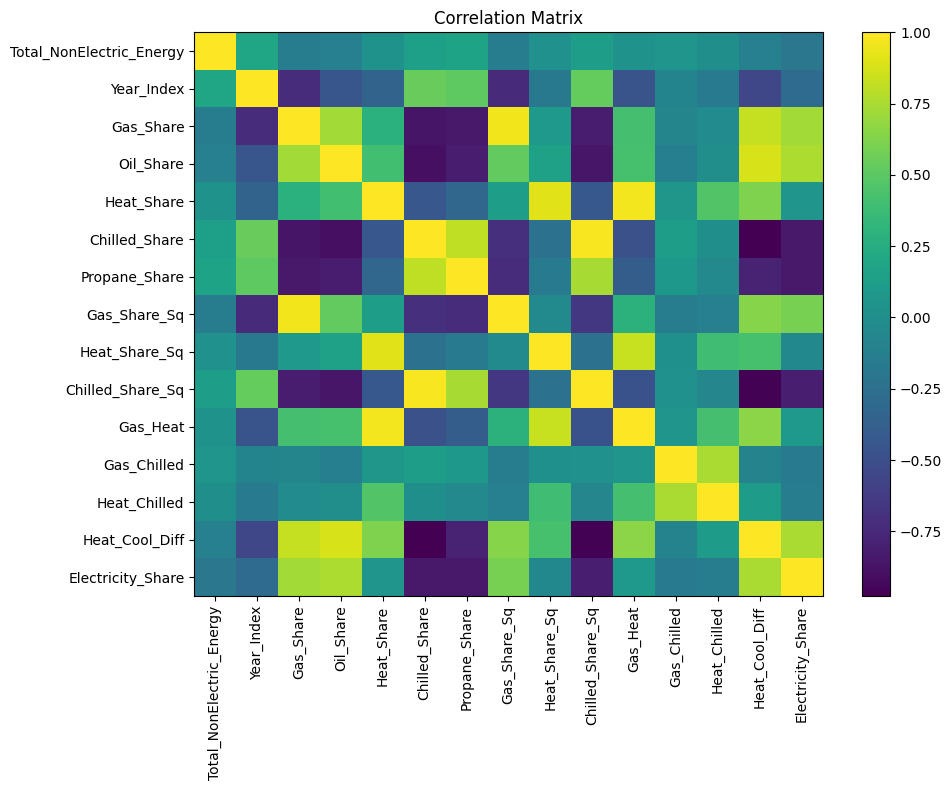


Correlation with Electricity_Share:
Electricity_Share           1.000000
Oil_Share                   0.754146
Heat_Cool_Diff              0.750077
Gas_Share                   0.727363
Gas_Share_Sq                0.591120
Gas_Heat                    0.085345
Heat_Share                  0.056205
Heat_Share_Sq              -0.056282
Heat_Chilled               -0.149457
Gas_Chilled                -0.155132
Total_NonElectric_Energy   -0.192555
Year_Index                 -0.285290
Chilled_Share_Sq           -0.806860
Propane_Share              -0.838520
Chilled_Share              -0.845043
Name: Electricity_Share, dtype: float64

Commercial electricity share model results:
Training samples: 651
Testing samples: 163

Model performance:
MSE: 0.0001981578702872821
RMSE: 0.01407685583812245
MAE: 0.009124873488980358
R²: 0.9894562386120457


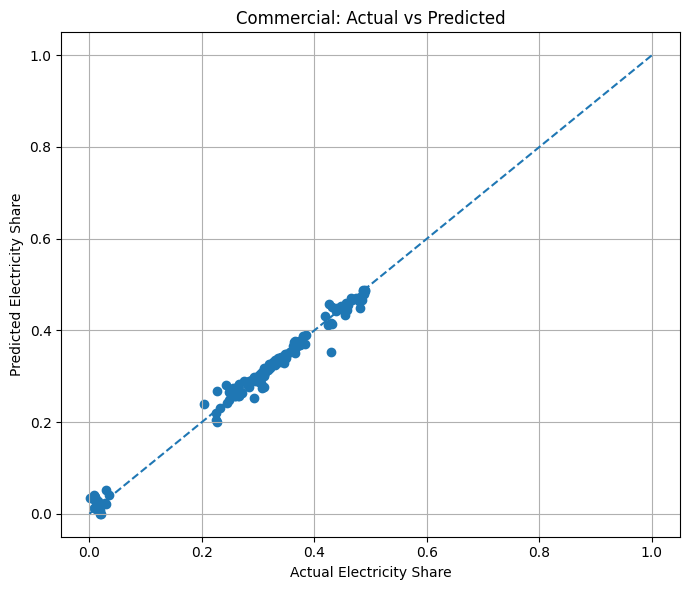

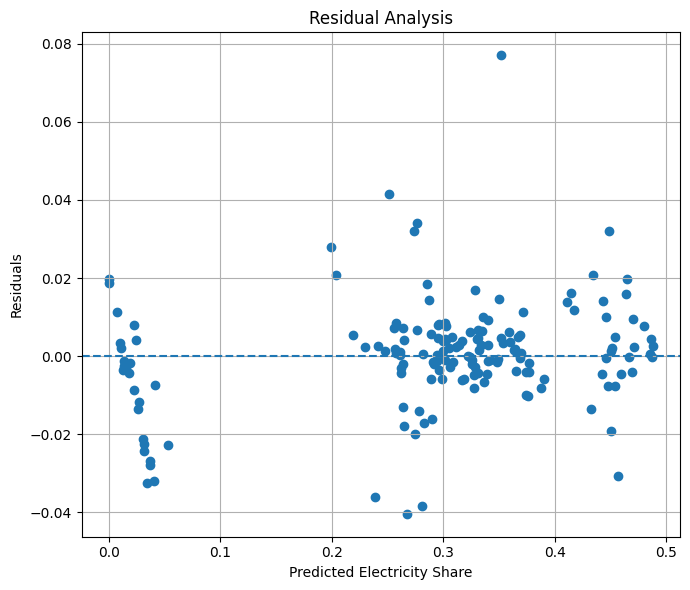

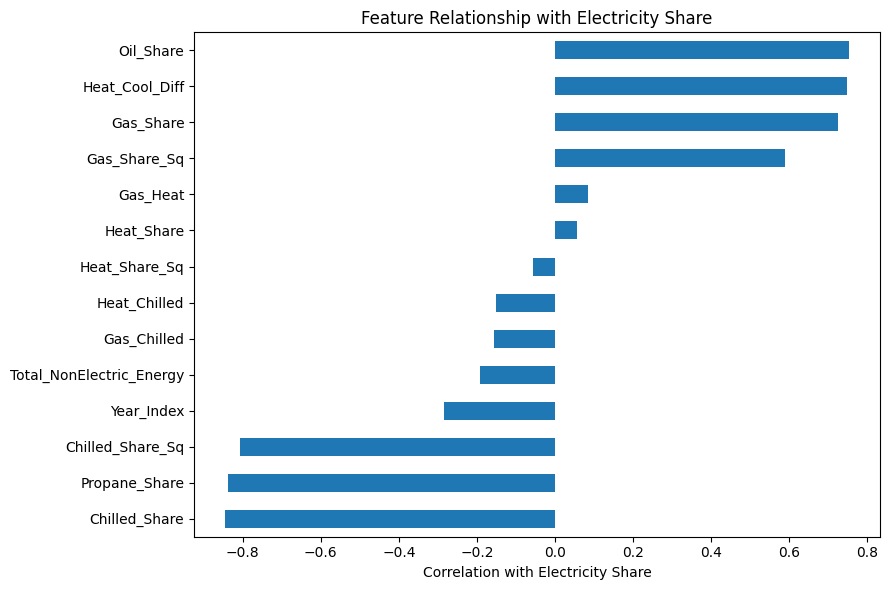

In [9]:
# ==============================
# Commercial Energy Electricity Share Model
# Fixed Full Code
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------
# 1. Upload files
# ------------------------------

uploaded = files.upload()
file_names = list(uploaded.keys())

print("Uploaded files:")
for f in file_names:
    print(f)

# ------------------------------
# 2. Load and clean EIA Excel table
# ------------------------------

def load_eia_table(file):
    raw = pd.read_excel(file, header=None)

    numeric_rows = []

    for i in range(len(raw)):
        numeric_row = pd.to_numeric(raw.iloc[i], errors="coerce")

        # Keep rows with enough numeric values
        if numeric_row.count() >= 6:
            numeric_rows.append(numeric_row)

    if len(numeric_rows) == 0:
        print(f"Skipping {file}: no usable numeric rows found")
        return None

    data = pd.DataFrame(numeric_rows)

    # Remove empty rows and columns
    data = data.dropna(how="all")
    data = data.dropna(axis=1, how="all")

    # Fix column mismatch issue
    if data.shape[1] < 7:
        print(f"Skipping {file}: only {data.shape[1]} columns found, expected 7")
        return None

    # Keep only first 7 numeric columns
    data = data.iloc[:, :7]

    data.columns = [
        "Total_Buildings",
        "Electricity",
        "Gas",
        "Oil",
        "Heat",
        "Chilled",
        "Propane"
    ]

    # Remove bad rows
    data = data.dropna()
    data = data[data["Total_Buildings"] > 0]
    data = data[data["Electricity"] >= 0]

    return data

# ------------------------------
# 3. Combine files
# ------------------------------

tables = []

for file in file_names:
    print(f"\nProcessing {file}...")
    temp = load_eia_table(file)

    if temp is not None and len(temp) > 0:
        tables.append(temp)

if len(tables) == 0:
    raise ValueError("No valid EIA tables were found. Check your uploaded files.")

combined_data = pd.concat(tables, ignore_index=True)

print("\nCombined data shape:", combined_data.shape)
print(combined_data.head())

# ------------------------------
# 4. Create energy totals and shares
# ------------------------------

energy_cols = [
    "Electricity",
    "Gas",
    "Oil",
    "Heat",
    "Chilled",
    "Propane"
]

combined_data["Total_Energy"] = combined_data[energy_cols].sum(axis=1)

combined_data = combined_data[combined_data["Total_Energy"] > 0].copy()

combined_data["Electricity_Share"] = combined_data["Electricity"] / combined_data["Total_Energy"]
combined_data["Gas_Share"] = combined_data["Gas"] / combined_data["Total_Energy"]
combined_data["Oil_Share"] = combined_data["Oil"] / combined_data["Total_Energy"]
combined_data["Heat_Share"] = combined_data["Heat"] / combined_data["Total_Energy"]
combined_data["Chilled_Share"] = combined_data["Chilled"] / combined_data["Total_Energy"]
combined_data["Propane_Share"] = combined_data["Propane"] / combined_data["Total_Energy"]

combined_data["Total_NonElectric_Energy"] = (
    combined_data["Gas"]
    + combined_data["Oil"]
    + combined_data["Heat"]
    + combined_data["Chilled"]
    + combined_data["Propane"]
)

combined_data["Year_Index"] = np.arange(len(combined_data))

# ------------------------------
# 5. Feature engineering
# ------------------------------

combined_data["Gas_Share_Sq"] = combined_data["Gas_Share"] ** 2
combined_data["Heat_Share_Sq"] = combined_data["Heat_Share"] ** 2
combined_data["Chilled_Share_Sq"] = combined_data["Chilled_Share"] ** 2

combined_data["Gas_Heat"] = combined_data["Gas_Share"] * combined_data["Heat_Share"]
combined_data["Gas_Chilled"] = combined_data["Gas_Share"] * combined_data["Chilled_Share"]
combined_data["Heat_Chilled"] = combined_data["Heat_Share"] * combined_data["Chilled_Share"]

combined_data["Heat_Cool_Diff"] = combined_data["Heat_Share"] - combined_data["Chilled_Share"]

combined_data = combined_data.replace([np.inf, -np.inf], np.nan)
combined_data = combined_data.dropna()

# ------------------------------
# 6. Features and target
# ------------------------------

features = [
    "Total_NonElectric_Energy",
    "Year_Index",
    "Gas_Share",
    "Oil_Share",
    "Heat_Share",
    "Chilled_Share",
    "Propane_Share",
    "Gas_Share_Sq",
    "Heat_Share_Sq",
    "Chilled_Share_Sq",
    "Gas_Heat",
    "Gas_Chilled",
    "Heat_Chilled",
    "Heat_Cool_Diff"
]

target = "Electricity_Share"

model_data = combined_data[features + [target]].copy()

print("\nModel data preview:")
print(model_data.head())

print("\nModel dataset shape:", model_data.shape)

X = model_data[features]
y = model_data[target]

# ------------------------------
# 7. Correlation matrix
# ------------------------------

corr = model_data.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("\nCorrelation with Electricity_Share:")
print(corr["Electricity_Share"].sort_values(ascending=False))

# ------------------------------
# 8. Train/test split
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ------------------------------
# 9. Scale features
# ------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------
# 10. MLP Neural Network
# ------------------------------

mlp_model = MLPRegressor(
    hidden_layer_sizes=(32, 16, 8),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=3000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50
)

mlp_model.fit(X_train_scaled, y_train)

# ------------------------------
# 11. Predictions
# ------------------------------

y_pred = mlp_model.predict(X_test_scaled)
y_pred = np.clip(y_pred, 0, 1)

# ------------------------------
# 12. Performance
# ------------------------------

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nCommercial electricity share model results:")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nModel performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

# ------------------------------
# 13. Actual vs Predicted
# ------------------------------

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Actual Electricity Share")
plt.ylabel("Predicted Electricity Share")
plt.title("Commercial: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------
# 14. Residual Analysis
# ------------------------------

residuals = y_test - y_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Electricity Share")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------
# 15. Feature relationship plot
# ------------------------------

feature_corr = corr["Electricity_Share"].drop("Electricity_Share").sort_values()

plt.figure(figsize=(9, 6))
feature_corr.plot(kind="barh")
plt.xlabel("Correlation with Electricity Share")
plt.title("Feature Relationship with Electricity Share")
plt.tight_layout()
plt.show()